# Data Vortex A'26 : Round 3 - Real-Time Analysis Notebook
## Topic 7 : Public Reaction to a Celebrity/Influencer Controversy

**Subject:** reported/alleged relationship between Tamil Nadu Chief Minister Vijay and actress Trisha Krishnan, and the surrounding political and fan commentary. Neither party has publicly confirmed the relationship : this notebook analyses *public reaction*, not the underlying claims.

**Input:** `live_dataset.csv` / `.json`, produced by `scraper.py` (Round 3 deliverable #1).
**Output:** the tables and figures this notebook produces feed directly into the mandatory Round 3 report sections : Sentiment Analysis, Activity Analysis, Topic/Entity Analysis, Trigger Explanations.

Run cells top to bottom. Re-run any time after `scraper.py` appends new rows to `live_dataset.csv` to update all charts.

In [1]:
import re, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)

sys.path.insert(0, ".")   # so `import round2_nlp` finds the file next to this notebook
from round2_nlp import repair_text, clean_text, meta_features, UnionVectorizer  # noqa: F401 (UnionVectorizer needed for joblib.load)
import joblib

DATA_CSV = "live_dataset.csv"
ENTITIES = ["vijay", "trisha", "udhayanidhi", "kangana", "tvk", "dmk", "sangeetha"]


## 1. Load & clean the live dataset

Loads whatever `scraper.py` has collected so far. Safe to re-run at any point during the 40-hour collection window , later rows just extend the timelines below.

In [2]:
df = pd.read_csv(DATA_CSV, dtype={"post_id": str, "parent_id": str})
df["created_utc"] = pd.to_datetime(df["created_utc"], utc=True, errors="coerce")
df = df.dropna(subset=["created_utc", "text"])
df = df.drop_duplicates(subset=["source", "post_id"]).reset_index(drop=True)
df["text"] = df["text"].astype(str)

print(f"{len(df)} records | {df['source'].nunique()} sources | "
      f"{df['created_utc'].min()} → {df['created_utc'].max()}")
df["source"].value_counts()


8854 records | 1 sources | 2017-08-28 16:26:57+00:00 → 2026-09-22 12:41:05+00:00


source
youtube    8854
Name: count, dtype: int64

## 1b. Restrict to the actual controversy window

`--sources youtube --yt-order relevance` deliberately surfaces the most-commented videos on
each query, not just the newest ones : that's what gave you the volume. But "most-commented"
also pulls in old, unrelated hits: a 2013 *Ghilli* song upload, old Vijay/Trisha fan-romance
edits, etc., whose comments span back to 2017–2018. Those aren't reactions to the current
controversy, and mixed into daily activity/sentiment they turn a clean spike into years of
near-flat noise (which is exactly the 2018→2027 chart you're seeing).

**Fix:** keep only records from the actual live collection window. Set `WINDOW_START` to
whenever you started scraping this story (check the earliest date in your scraper log, or
just use a safe round number like 30 days back). Everything below this cell now runs on the
filtered `df` re-run from here down after changing the date.

In [3]:
WINDOW_START = pd.Timestamp("2026-08-20", tz="UTC")  # <-- adjust to when you actually started collecting

before = len(df)
df = df[df["created_utc"] >= WINDOW_START].reset_index(drop=True)
print(f"Kept {len(df)} / {before} records from {WINDOW_START.date()} onward "
      f"(dropped {before - len(df)} older, off-topic hits from evergreen/nostalgia videos)")
df["created_utc"].describe()


Kept 1994 / 8854 records from 2026-08-20 onward (dropped 6860 older, off-topic hits from evergreen/nostalgia videos)


count                                   1994
mean     2026-09-13 06:10:36.855065344+00:00
min                2026-08-20 07:18:41+00:00
25%         2026-09-11 06:47:47.500000+00:00
50%                2026-09-14 11:39:24+00:00
75%                2026-09-18 04:10:34+00:00
max                2026-09-22 12:41:05+00:00
Name: created_utc, dtype: object

## 2. Language flag

The Round 2 sentiment/topic models were trained on English text only, and VADER (used inside the Round 2 meta-features) is English-only too. A lot of this conversation will be in Tamil script or **Tanglish** (Tamil written in Latin letters), so:

- `ta` : Tamil script detected → excluded from the Round 2 model predictions.
- `en` : Latin script, no Tamil characters → passed to the Round 2 models. This still includes Tanglish, which the models were not trained on either : flag this as a limitation in the report rather than treating `en` predictions as uniformly reliable.
- `mixed` : both scripts in the same post.

All three groups are kept for volume and entity-count analysis; only `en` gets a sentiment/topic label.

In [4]:
TAMIL_RE = re.compile(r"[\u0B80-\u0BFF]")

# Common Tamil words frequently seen in Tanglish.
# This is intentionally conservative.
TANGLISH_WORDS = {
    "romba", "nalla", "illa", "illai", "iruku", "irukku",
    "irundhu", "iruntha", "enna", "epdi", "eppadi",
    "pannunga", "panra", "pannanum", "pannitu", "pannitu",
    "poga", "poguthu", "poitu", "vara", "varum", "vanthu",
    "vandhu", "nee", "neenga", "unga", "ungaluku",
    "ungalukku", "enaku", "enakku", "avanga", "avan", "ava",
    "ivanga", "ivaru", "akka", "anna", "thambi", "thangachi",
    "sollu", "solra", "sonna", "sollunga",
    "kandippa", "summa", "maari", "mathiri",
    "pidikala", "pidikkala", "pidikum", "pidikkum",
    "thappu", "semma", "mokka", "dei", "da", "di",
    "mam", "amma", "appa", "kodunga", "kodukathinga",
    "venam", "vendam", "theriyum", "therila", "theriyathu",
    "paatha", "paarunga", "parunga", "yen", "yenga",
    "enga", "inge", "ange"
}


def flag_lang(text):
    text = str(text)

    has_tamil = bool(TAMIL_RE.search(text))

    words = re.findall(r"[A-Za-z]+", text.lower())

    tanglish_hits = sum(
        word in TANGLISH_WORDS
        for word in words
    )

    # Tamil + Latin characters
    if has_tamil and words:
        return "mixed"

    # Pure Tamil script
    if has_tamil:
        return "ta"

    # Latin-script Tamil/Tanglish
    if tanglish_hits >= 2:
        return "tanglish"

    return "en"


df["lang"] = df["text"].apply(flag_lang)

print(df["lang"].value_counts())
print("\nProportion:")
print(df["lang"].value_counts(normalize=True).round(3))

lang
en          1366
ta           471
mixed         80
tanglish      77
Name: count, dtype: int64

Proportion:
lang
en          0.685
ta          0.236
mixed       0.040
tanglish    0.039
Name: proportion, dtype: float64


In [5]:
%pip install googletrans==4.0.0-rc1

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Quick translation-quality check
# This cell does NOT modify the main dataset.

import random
from googletrans import Translator

SAMPLE_N = 15
random.seed(0)

candidates = df[
    df["lang"].isin(["ta", "mixed", "tanglish"])
]["text"].dropna().astype(str).tolist()

sample_texts = random.sample(
    candidates,
    min(SAMPLE_N, len(candidates))
)

translator = Translator()

for i, text in enumerate(sample_texts, 1):

    try:
        translated = translator.translate(
            text,
            src="auto",
            dest="en"
        ).text

        print(f"\n{'='*80}")
        print(f"SAMPLE {i}")
        print("ORIGINAL   :", text)
        print("TRANSLATED :", translated)

    except Exception as e:
        print(f"\nSAMPLE {i}")
        print("ORIGINAL   :", text)
        print("ERROR      :", e)


SAMPLE 1
ORIGINAL   : ஒரு பொண்டாட்டிக்கு என்ன வலி இருக்குமோ அந்த வலி இந்த வலி
TRANSLATED : This pain is the pain that a baby feels

SAMPLE 2
ORIGINAL   : நீ பூமியில் வாழ்வதே சாபக்கேடு
TRANSLATED : You are cursed to live on earth

SAMPLE 3
ORIGINAL   : ஏங்க நீங்க வேற பயமுறுத்துறீங்க. அது எப்படி இப்படி யோசிக்கிறீங்க.
TRANSLATED : Do you want to scare someone else?How can you think like this?

SAMPLE 4
ORIGINAL   : நம் நாட்டில் விஜய் திரிஷா தவிர பேச எதுவுமே இல்லையா இன்று நம் பிரதமர் நடத்தும் மாநாடு வெளிநாட்டு தலைவர்களின் வருகை அதனால் நம் நாட்டிற்கு ஏற்படும் நன்மைகள் இதைப் பற்றி கொஞ்சம் இளைஞர்கள் சிந்தியுங்கள் விஜய் திரிஷா சங்கீதா இவர்களிடம் எக்கச்சக்க பணம் உள்ளது எப்படியும் வாழலாம் ஆனால் நம்மிடம்?
TRANSLATED : There is nothing to talk about except Vijay Trisha in our country Today the conference held by our Prime Minister is the visit of foreign leaders so the benefits of our country think about this a little youths Vijay Trisha Sangeeta They have a lot of money they can live anyway but 

In [8]:
from googletrans import Translator
import time

translator = Translator()

# Preserve original text
df["translated_text"] = df["text"].astype(str)

# Translate Tamil, Tanglish and mixed posts only
translation_mask = df["lang"].isin(
    ["ta", "mixed", "tanglish"]
)

translation_indices = df.index[translation_mask]

print("Total records:", len(df))
print("English records:", (df["lang"] == "en").sum())
print("Records requiring translation:", len(translation_indices))

translation_errors = 0

for count, idx in enumerate(translation_indices, 1):

    original = str(df.loc[idx, "text"])

    try:

        result = translator.translate(
            original,
            src="auto",
            dest="en"
        )

        df.loc[idx, "translated_text"] = result.text

    except Exception as e:

        translation_errors += 1

        # If translation fails, keep original
        df.loc[idx, "translated_text"] = original

        print(f"Translation error at row {idx}: {e}")

    # Save checkpoint
    if count % 100 == 0:

        df.to_csv(
            "translated_checkpoint.csv",
            index=False
        )

        print(
            f"Translated {count}/{len(translation_indices)}"
        )

    # Small delay
    time.sleep(0.2)

print("\nTranslation complete.")
print("Translation errors:", translation_errors)

print("\nLanguage distribution:")
print(df["lang"].value_counts())

Total records: 1994
English records: 1366
Records requiring translation: 628
Translated 100/628
Translated 200/628
Translated 300/628
Translated 400/628
Translated 500/628
Translated 600/628

Translation complete.
Translation errors: 0

Language distribution:
lang
en          1366
ta           471
mixed         80
tanglish      77
Name: count, dtype: int64


In [19]:
# Translation Quality Audit

audit_mask = df["lang"].isin(
    ["ta", "mixed", "tanglish"]
)

audit_df = df.loc[
    audit_mask,
    ["text", "lang", "translated_text"]
].sample(
    min(100, audit_mask.sum()),
    random_state=42
).copy()

# Add columns for manual evaluation
audit_df["translation_quality"] = ""
audit_df["sentiment_preserved"] = ""

audit_df.to_csv(
    "translation_quality_audit.csv",
    index=False
)

print("Translation audit file created.")
print("Number of samples:", len(audit_df))
print("\nOpen translation_quality_audit.csv")
print("Mark each row:")
print("translation_quality → Good / Acceptable / Bad")
print("sentiment_preserved → Yes / No")

Translation audit file created.
Number of samples: 100

Open translation_quality_audit.csv
Mark each row:
translation_quality → Good / Acceptable / Bad
sentiment_preserved → Yes / No


In [9]:
# Use translated English as the model input
df["model_text"] = df["translated_text"]

# Check a few examples
df[
    ["text", "lang", "translated_text"]
].sample(
    min(10, len(df)),
    random_state=42
)

,text,lang,translated_text
889,If he is not going to unite with his family an...,en,If he is not going to unite with his family an...
1672,Thurkuri Vetti Kazagam takes our TN backwards.,en,Thurkuri Vetti Kazagam takes our TN backwards.
414,Jab ek chaiwala CM Ban jaega to Desh bech dega...,en,Jab ek chaiwala CM Ban jaega to Desh bech dega...
1599,ஏன்டி எல்லா அரசியல் தலைவர்கள் அவர்கள் குடும்ப ...,ta,Why did all the political leaders go with thei...
849,Idhula unakena prachana,en,Idhula unakena prachana
1658,Vanitha Akka Thirisha ku konjam Advice pannu...,en,Vanitha Akka Thirisha ku konjam Advice pannu...
926,Oh God ... This leader is a disgrace very bad...,en,Oh God ... This leader is a disgrace very bad...
1670,அக்கா எவ்வளவு பெரிய ஆதாரத்தை கொடுத்திருக்கீங்க...,ta,"Thank you very much sister, what a great sourc..."
1448,"விஜய் திரிஷா தொடர்பு,விஜய்யின் அரசியல் வாழ்வை...",ta,Vijay Trisha relationship has ruined Vijay's p...
1216,த்ரிஷா movie show kku poirugaga.திரிஷா vijay...,mixed,Vijay Kku Suniyakari Than


In [ ]:
# ==========================================
# SENTIMENT EVALUATION - STEP 1
# Create evaluation sample
# ==========================================

import pandas as pd

eval_df = df[
    df["lang"].isin(["ta", "mixed", "tanglish"])
].sample(
    n=min(
        100,
        len(df[df["lang"].isin(["ta", "mixed", "tanglish"])])
    ),
    random_state=42
).copy()

# Save the original text, translation and model prediction
eval_df[
    ["text", "lang", "translated_text", "sentiment"]
].to_csv(
    "sentiment_evaluation.csv",
    index=False
)

print("Evaluation file created!")
print("Number of samples:", len(eval_df))
print("\nFile: sentiment_evaluation.csv")
print("\nIMPORTANT:")
print("Open the CSV and add a column named:")
print("human_sentiment")
print("\nAllowed values:")
print("Positive")
print("Negative")
print("Neutral")

Evaluation file created!
Number of samples: 100

File: sentiment_evaluation.csv

IMPORTANT:
Open the CSV and add a column named:
human_sentiment

Allowed values:
Positive
Negative
Neutral


## 3. Apply the Round 2 models

Loads the pickled vectorizer + model pairs saved by `Round2_NLP_Notebook.ipynb` (run that notebook first if `models/` doesn't exist yet). Predicts on `lang == "en"` rows only; everything else is left unlabeled (`None`).

In [26]:

MODEL_DIR = "models"

model_paths = {
    "sentiment": (
        f"{MODEL_DIR}/vectorizer_sentiment_classification.pkl",
        f"{MODEL_DIR}/model_sentiment_classification.pkl"
    ),
    "topic": (
        f"{MODEL_DIR}/vectorizer_topic_classification.pkl",
        f"{MODEL_DIR}/model_topic_classification.pkl"
    ),
}

import os

models_available = all(
    os.path.exists(p)
    for pair in model_paths.values()
    for p in pair
)

# Use translated English text for the models
df["model_text"] = df["translated_text"].fillna(df["text"])

df["repaired_text"] = df["model_text"].apply(repair_text)
df["clean_text"] = df["repaired_text"].apply(clean_text)

df["sentiment"] = None
df["topic"] = None


if models_available:

    meta = meta_features(
        df["repaired_text"].values
    )

    # All rows now have model-compatible text
    model_mask = df["model_text"].notna()

    sent_vec, sent_model = (
        joblib.load(model_paths["sentiment"][0]),
        joblib.load(model_paths["sentiment"][1])
    )

    topic_vec, topic_model = (
        joblib.load(model_paths["topic"][0]),
        joblib.load(model_paths["topic"][1])
    )

    X_sent = sent_vec.transform(
        df.loc[model_mask, "clean_text"].values,
        meta[model_mask.values]
    )

    X_topic = topic_vec.transform(
        df.loc[model_mask, "clean_text"].values,
        meta[model_mask.values]
    )

    df.loc[model_mask, "sentiment"] = (
        sent_model.predict(X_sent)
    )

    df.loc[model_mask, "topic"] = (
        topic_model.predict(X_topic)
    )

    print(
        "Predicted sentiment + topic for",
        model_mask.sum(),
        "records."
    )

else:

    print(
        "models/ not found : run Round2_NLP_Notebook.ipynb first."
    )

print("\nSentiment distribution:")
print(df["sentiment"].value_counts(dropna=False))




C:\Users\KEERTHANA SRI D\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\KEERTHANA SRI D\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\KEERTHANA SRI D\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimat

Predicted sentiment + topic for 1994 records.

Sentiment distribution:
sentiment
Neutral     776
Negative    645
Positive    573
Name: count, dtype: int64


In [27]:
# ==========================================
# TRANSLATION + SENTIMENT PIPELINE EVALUATION
# ==========================================

import pandas as pd
import numpy as np

# -----------------------------
# 1. Translation coverage
# -----------------------------

translation_required = df["lang"].isin(
    ["ta", "mixed", "tanglish"]
)

translated_successfully = (
    translation_required &
    df["translated_text"].notna() &
    (df["translated_text"].str.strip() != "")
)

translation_coverage = (
    translated_successfully.sum()
    / translation_required.sum()
    * 100
)

print("=== TRANSLATION EVALUATION ===")
print(f"Total records              : {len(df)}")
print(f"Records requiring translation: {translation_required.sum()}")
print(f"Successfully translated     : {translated_successfully.sum()}")
print(f"Translation coverage        : {translation_coverage:.2f}%")

# -----------------------------
# 2. Translation failures
# -----------------------------

translation_failures = (
    translation_required &
    ~translated_successfully
)

print(
    f"Translation failures       : "
    f"{translation_failures.sum()}"
)

# -----------------------------
# 3. Language distribution
# -----------------------------

print("\n=== LANGUAGE DISTRIBUTION ===")

print(
    df["lang"].value_counts()
)

print("\nPercentage:")

print(
    (df["lang"].value_counts(normalize=True) * 100)
    .round(2)
)

# -----------------------------
# 4. Sentiment coverage
# -----------------------------

sentiment_available = df["sentiment"].notna()

sentiment_coverage = (
    sentiment_available.sum()
    / len(df)
    * 100
)

print("\n=== SENTIMENT COVERAGE ===")

print(
    f"Records with sentiment : "
    f"{sentiment_available.sum()}"
)

print(
    f"Sentiment coverage     : "
    f"{sentiment_coverage:.2f}%"
)

# -----------------------------
# 5. Sentiment distribution
# -----------------------------

print("\n=== SENTIMENT DISTRIBUTION ===")

sentiment_distribution = (
    df["sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(
    sentiment_distribution.round(2)
)

# -----------------------------
# 6. Sentiment by language
# -----------------------------

print("\n=== SENTIMENT BY LANGUAGE ===")

sentiment_by_language = pd.crosstab(
    df["lang"],
    df["sentiment"],
    normalize="index"
) * 100

print(
    sentiment_by_language.round(2)
)

=== TRANSLATION EVALUATION ===
Total records              : 1994
Records requiring translation: 628
Successfully translated     : 628
Translation coverage        : 100.00%
Translation failures       : 0

=== LANGUAGE DISTRIBUTION ===
lang
en          1366
ta           471
mixed         80
tanglish      77
Name: count, dtype: int64

Percentage:
lang
en          68.51
ta          23.62
mixed        4.01
tanglish     3.86
Name: proportion, dtype: float64

=== SENTIMENT COVERAGE ===
Records with sentiment : 1994
Sentiment coverage     : 100.00%

=== SENTIMENT DISTRIBUTION ===
sentiment
Neutral     38.92
Negative    32.35
Positive    28.74
Name: proportion, dtype: float64

=== SENTIMENT BY LANGUAGE ===
sentiment  Negative  Neutral  Positive
lang                                  
en            25.77    41.07     33.16
mixed         63.75    18.75     17.50
ta            44.37    36.09     19.53
tanglish      42.86    38.96     18.18


## 4. Activity analysis : volume over time & engagement-spike detection

Bucket by hour (fine-grained, for the live window) and by day (for the whole collection period), then flag spikes against a rolling local baseline: previous-3-bucket mean/std, excluding the bucket itself, so a spike doesn't smooth away its own signal. A bucket is flagged if it's at least 1.75× the baseline mean **or** at least 2 baseline standard deviations above it : the ratio test catches spikes even when the recent baseline was near-constant (std ≈ 0).

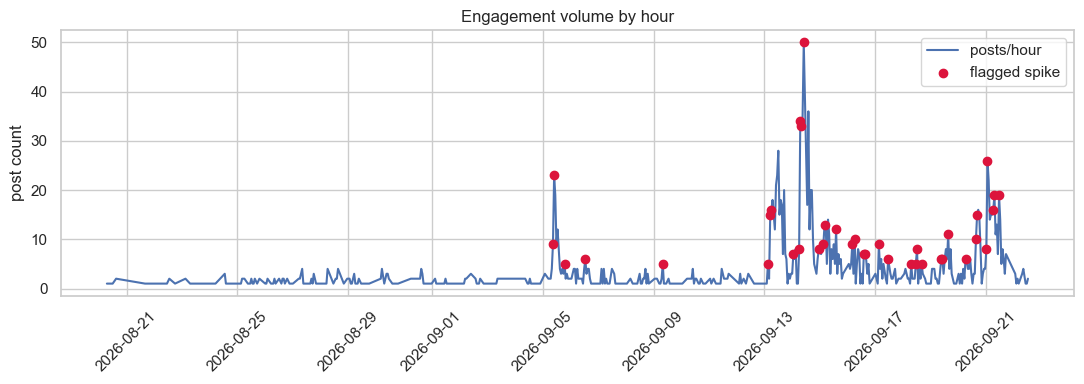

Flagged 38 hourly spike(s). Need at least 1 engagement spike for the report:


,volume,baseline_mean
hour,,
2026-09-05 09:00:00+00:00,9,2.666667
2026-09-05 10:00:00+00:00,23,5.000000
2026-09-05 19:00:00+00:00,5,3.333333
2026-09-06 13:00:00+00:00,6,2.333333
2026-09-09 08:00:00+00:00,5,1.333333
2026-09-13 03:00:00+00:00,5,1.000000
2026-09-13 05:00:00+00:00,15,2.666667
2026-09-13 06:00:00+00:00,16,7.333333
2026-09-14 01:00:00+00:00,7,2.666667


In [11]:
def detect_spikes(series, min_count=5, ratio=1.75, z=2.0):
    """series: a count-per-bucket pd.Series indexed by time. Returns a DataFrame with spike flags."""
    out = series.rename("volume").to_frame()
    baseline_mean = series.shift(1).rolling(3, min_periods=1).mean()
    baseline_std = series.shift(1).rolling(3, min_periods=1).std().fillna(0)
    out["baseline_mean"] = baseline_mean
    out["baseline_std"] = baseline_std
    ratio_flag = out["volume"] >= ratio * out["baseline_mean"]
    z_flag = (out["baseline_std"] > 0) & ((out["volume"] - out["baseline_mean"]) >= z * out["baseline_std"])
    out["is_spike"] = (out["volume"] >= min_count) & out["baseline_mean"].notna() & (ratio_flag | z_flag)
    return out

df["hour"] = df["created_utc"].dt.floor("h")
df["date"] = df["created_utc"].dt.floor("D")

hourly = detect_spikes(df.groupby("hour").size())
daily = detect_spikes(df.groupby("date").size())

fig, ax = plt.subplots()
ax.plot(hourly.index, hourly["volume"], color="#4C72B0", label="posts/hour")
spikes_h = hourly[hourly["is_spike"]]
ax.scatter(spikes_h.index, spikes_h["volume"], color="crimson", zorder=5, label="flagged spike")
ax.set_title("Engagement volume by hour"); ax.set_ylabel("post count"); ax.legend()
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f"Flagged {spikes_h.shape[0]} hourly spike(s). Need at least 1 engagement spike for the report:")
spikes_h[["volume", "baseline_mean"]]


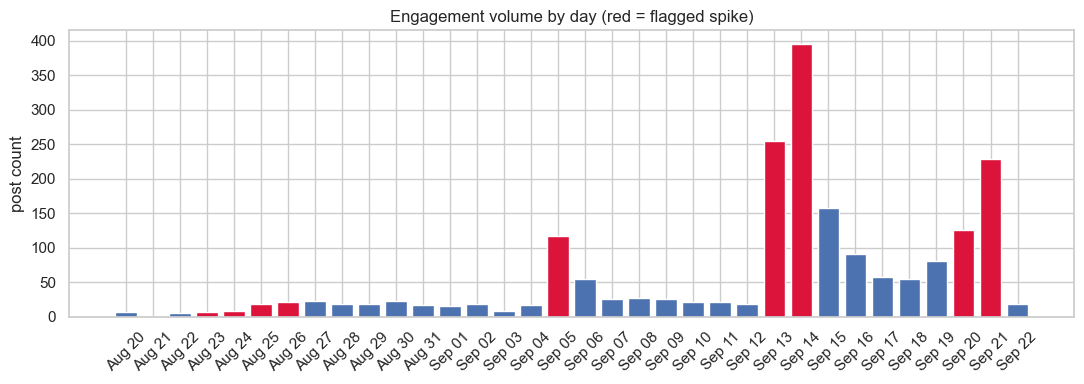

source,youtube
date,
2026-08-20 00:00:00+00:00,6
2026-08-21 00:00:00+00:00,1
2026-08-22 00:00:00+00:00,5
2026-08-23 00:00:00+00:00,7
2026-08-24 00:00:00+00:00,8
2026-08-25 00:00:00+00:00,18
2026-08-26 00:00:00+00:00,21
2026-08-27 00:00:00+00:00,22
2026-08-28 00:00:00+00:00,18


In [12]:
fig, ax = plt.subplots()
ax.bar(daily.index.strftime("%b %d"), daily["volume"], color=["crimson" if s else "#4C72B0" for s in daily["is_spike"]])
ax.set_title("Engagement volume by day (red = flagged spike)"); ax.set_ylabel("post count")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

df.groupby(["date", "source"]).size().unstack(fill_value=0)


## 5. Sentiment analysis over time & shift detection

Daily sentiment mix (English-language subset only - see Section 2), plus a simple shift detector: a **shift** is flagged wherever the day-over-day change in negative-sentiment share exceeds a threshold. Needs at least 2 sentiment shifts for the report, lower `SHIFT_THRESHOLD` if fewer than 2 show up once you have enough data, but note in the report whatever threshold you actually used.

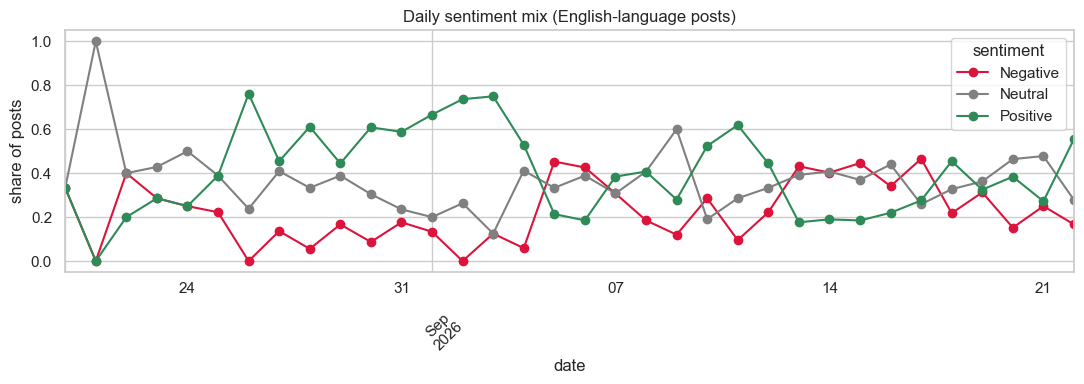

Flagged 17 day(s) with a sentiment shift ≥ 15%. Need at least 2 for the report:


sentiment,Negative,Neutral,Positive,neg_share_delta,pos_share_delta
date,,,,,
2026-08-21 00:00:00+00:00,0.000000,1.000000,0.000000,-0.333333,-0.333333
2026-08-22 00:00:00+00:00,0.400000,0.400000,0.200000,0.400000,0.200000
2026-08-26 00:00:00+00:00,0.000000,0.238095,0.761905,-0.222222,0.373016
2026-08-27 00:00:00+00:00,0.136364,0.409091,0.454545,0.136364,-0.307359
2026-08-28 00:00:00+00:00,0.055556,0.333333,0.611111,-0.080808,0.156566
2026-08-29 00:00:00+00:00,0.166667,0.388889,0.444444,0.111111,-0.166667
2026-08-30 00:00:00+00:00,0.086957,0.304348,0.608696,-0.079710,0.164251
2026-09-04 00:00:00+00:00,0.058824,0.411765,0.529412,-0.066176,-0.220588
2026-09-05 00:00:00+00:00,0.452991,0.333333,0.213675,0.394168,-0.315737


In [13]:
SHIFT_THRESHOLD = 0.15   # flag if |change in negative share| exceeds this between consecutive days

sent_df = df[df["sentiment"].notna()]
sent_daily = (sent_df.groupby("date")["sentiment"]
              .value_counts(normalize=True).unstack(fill_value=0)
              .reindex(columns=["Negative", "Neutral", "Positive"], fill_value=0))

fig, ax = plt.subplots()
sent_daily.plot(ax=ax, marker="o", color={"Negative": "crimson", "Neutral": "gray", "Positive": "seagreen"})
ax.set_title("Daily sentiment mix (English-language posts)"); ax.set_ylabel("share of posts")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

sent_daily["neg_share_delta"] = sent_daily["Negative"].diff()
sent_daily["pos_share_delta"] = sent_daily["Positive"].diff()
shifts = sent_daily[(sent_daily["neg_share_delta"].abs() >= SHIFT_THRESHOLD) |
                     (sent_daily["pos_share_delta"].abs() >= SHIFT_THRESHOLD)]

print(f"Flagged {len(shifts)} day(s) with a sentiment shift ≥ {SHIFT_THRESHOLD:.0%}. Need at least 2 for the report:")
shifts[["Negative", "Neutral", "Positive", "neg_share_delta", "pos_share_delta"]]


## 6. Topic / entity analysis

Two views: the Round 2 `topic_category` label distribution (Community_Discussion / Technical_Issues / Feature_Feedback / Account_Security : note these Round 2 categories were designed for a product-feedback dataset, not celebrity gossip, so expect most Round 3 posts to fall into `Community_Discussion`; call this out in the report rather than over-interpreting it), and a direct keyword count of the specific entities in this story (Vijay, Trisha, Udhayanidhi, Kangana, TVK, DMK, Sangeetha) per day, which is the more informative signal for this topic.

In [18]:
topic_daily = (
    df[df["topic"].notna()]
    .groupby("date")["topic"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

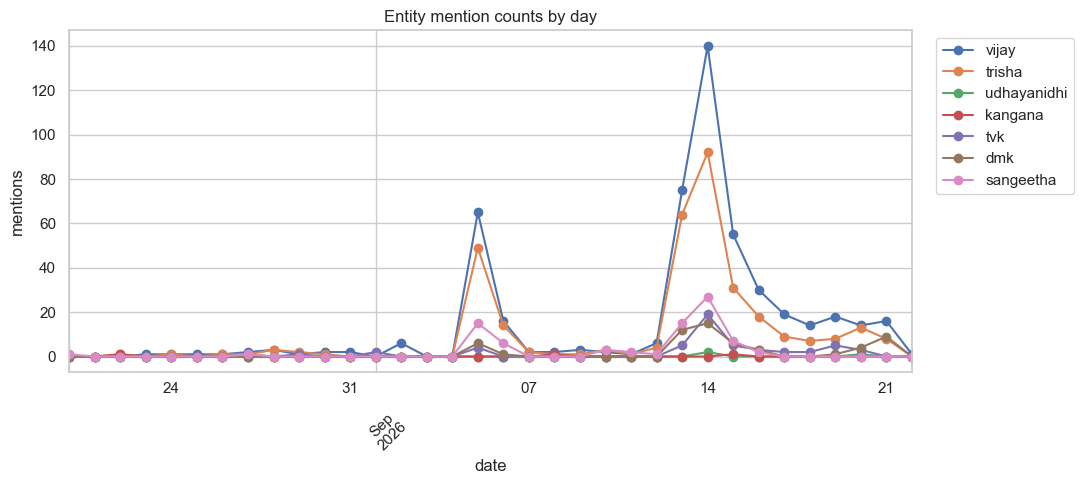

,vijay,trisha,udhayanidhi,kangana,tvk,dmk,sangeetha
date,,,,,,,
2026-08-20 00:00:00+00:00,0,0,0,0,0,0,1
2026-08-21 00:00:00+00:00,0,0,0,0,0,0,0
2026-08-22 00:00:00+00:00,0,1,0,1,0,0,0
2026-08-23 00:00:00+00:00,1,0,0,0,0,0,0
2026-08-24 00:00:00+00:00,1,1,0,0,0,0,0
2026-08-25 00:00:00+00:00,1,0,0,0,0,0,0
2026-08-26 00:00:00+00:00,1,1,0,0,0,0,0
2026-08-27 00:00:00+00:00,2,1,0,0,1,0,1
2026-08-28 00:00:00+00:00,3,3,0,0,0,0,0


In [15]:
def count_entities(text, entities=ENTITIES):
    t = text.lower()
    return {e: len(re.findall(rf"\b{re.escape(e)}\b", t)) for e in entities}

ent_counts = df["clean_text"].apply(count_entities).apply(pd.Series)
ent_daily = pd.concat([df["date"], ent_counts], axis=1).groupby("date").sum()

fig, ax = plt.subplots(figsize=(11, 5))
ent_daily.plot(ax=ax, marker="o")
ax.set_title("Entity mention counts by day"); ax.set_ylabel("mentions")
plt.xticks(rotation=45); plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()

ent_daily


## 7. Trigger explanations : lining up spikes/shifts with news

Pulls the `gdelt_news` rows already inside `live_dataset.csv` (collected by `scraper.py --sources gdelt`) around each flagged spike/shift date, as a starting point for the "Reasons behind observed changes" section. Read the headlines and write the actual explanation in the report : this cell only surfaces candidates, it doesn't interpret them.

In [16]:
flagged_dates = sorted(set(spikes_h.index.floor("D")) | set(shifts.index))
news = df[df["source"] == "gdelt_news"].copy()

for d in flagged_dates:
    window = news[(news["date"] >= d - pd.Timedelta(days=1)) & (news["date"] <= d + pd.Timedelta(days=1))]
    print(f"\n=== {d.strftime('%Y-%m-%d')} ± 1 day: {len(window)} news headline(s) ===")
    for _, row in window.sort_values('created_utc').iterrows():
        print(f"  [{row['created_utc'].strftime('%Y-%m-%d %H:%M')}] {row['text'][:110]}")
    if window.empty:
        print("  (none collected : widen --gdelt-timespan on the next scraper run, or check other sources' text around this date)")



=== 2026-08-21 ± 1 day: 0 news headline(s) ===
  (none collected — widen --gdelt-timespan on the next scraper run, or check other sources' text around this date)

=== 2026-08-22 ± 1 day: 0 news headline(s) ===
  (none collected — widen --gdelt-timespan on the next scraper run, or check other sources' text around this date)

=== 2026-08-26 ± 1 day: 0 news headline(s) ===
  (none collected — widen --gdelt-timespan on the next scraper run, or check other sources' text around this date)

=== 2026-08-27 ± 1 day: 0 news headline(s) ===
  (none collected — widen --gdelt-timespan on the next scraper run, or check other sources' text around this date)

=== 2026-08-28 ± 1 day: 0 news headline(s) ===
  (none collected — widen --gdelt-timespan on the next scraper run, or check other sources' text around this date)

=== 2026-08-29 ± 1 day: 0 news headline(s) ===
  (none collected — widen --gdelt-timespan on the next scraper run, or check other sources' text around this date)

=== 2026-08-30 ± 1 da

C:\Users\KEERTHANA SRI D\AppData\Local\Temp\ipykernel_21656\743576031.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = news[(news["date"] >= d - pd.Timedelta(days=1)) & (news["date"] <= d + pd.Timedelta(days=1))]
C:\Users\KEERTHANA SRI D\AppData\Local\Temp\ipykernel_21656\743576031.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = news[(news["date"] >= d - pd.Timedelta(days=1)) & (news["date"] <= d + pd.Timedelta(days=1))]
C:\Users\KEERTHANA SRI D\AppData\Local\Temp\ipykernel_21656\743576031.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit 

## 8. Export summary tables for the report

Writes the key tables/figures already rendered above to `outputs/` so they can be dropped straight into the Round 3 PDF report.

In [17]:
import os
os.makedirs("outputs", exist_ok=True)

daily.to_csv("outputs/daily_volume_spikes.csv")
hourly.to_csv("outputs/hourly_volume_spikes.csv")
sent_daily.to_csv("outputs/sentiment_daily.csv")
topic_daily.to_csv("outputs/topic_daily.csv")
ent_daily.to_csv("outputs/entity_daily.csv")

summary = {
    "records_total": int(len(df)),
    "date_range": [str(df['created_utc'].min()), str(df['created_utc'].max())],
    "sources": df["source"].value_counts().to_dict(),
    "lang_mix": df["lang"].value_counts(normalize=True).round(3).to_dict(),
    "translation_required": int(
    df["lang"].isin(["ta", "mixed", "tanglish"]).sum()),
    "n_spikes_hourly": int(spikes_h.shape[0]),
    "n_sentiment_shifts": int(len(shifts)),
}
with open("outputs/summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Saved to outputs/:")
for f in sorted(os.listdir("outputs")):
    print(" -", f)
summary


Saved to outputs/:
 - daily_volume_spikes.csv
 - entity_daily.csv
 - hourly_volume_spikes.csv
 - sentiment_daily.csv
 - summary.json
 - topic_daily.csv


{'records_total': 1994,
 'date_range': ['2026-08-20 07:18:41+00:00', '2026-09-22 12:41:05+00:00'],
 'sources': {'youtube': 1994},
 'lang_mix': {'en': 0.685, 'ta': 0.236, 'mixed': 0.04, 'tanglish': 0.039},
 'translation_required': 628,
 'n_spikes_hourly': 38,
 'n_sentiment_shifts': 17}